# NumPy Basics: Numerical Computing in Python

**Objective:** Learn the fundamentals of NumPy (creating arrays, operations, indexing, filtering, statistics) and then apply them to the real BigBasket product dataset.

**Dataset:** `../data/BigBasket_Products.csv` (27,555 products x 10 columns), used in Section 9. Sections 1 to 8 use small example arrays.

---

## Notebook Contents

| Section | Topic |
|---------|-------|
| 1 | Getting Started: what NumPy is, why it is fast |
| 2 | Creating Arrays |
| 3 | Array Attributes and Type Conversion |
| 4 | Array Operations and Math Functions |
| 5 | Aggregations and Statistics |
| 6 | Indexing, Slicing and Boolean Filtering |
| 7 | Reshaping, Sorting and Combining Arrays |
| 8 | Handling Missing Values (NaN) |
| 9 | NumPy on the BigBasket Dataset |
| 10 | Images as Arrays |
| 11 | Summary |

# Section 1: Getting Started

## What is NumPy and Why It Is Essential
- **NumPy (Numerical Python)** is a powerful library for numerical computing in Python.
- Provides support for **multi-dimensional arrays** and **mathematical operations** on them.
- Essential because:
  - Efficient storage and manipulation of large datasets.
  - Faster computations compared to Python lists.
  - Foundation for many scientific libraries (Pandas, SciPy, scikit-learn, etc.).

---

## Installing NumPy
Using **pip**:

```bash
pip install numpy
```

In [1]:
# Install once if needed (run in a terminal, or put ! in front inside Jupyter):
# pip install numpy

In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Why is NumPy faster than a Python list?

- NumPy arrays store **one data type** in a continuous block of memory.
- Operations run in optimized **C code** instead of a slow Python loop.
- You write `a * 2` instead of looping over every element (this is called **vectorization**).

Let us measure it by squaring one million numbers both ways.

In [3]:
import time

n = 1_000_000
py_list = list(range(n))
np_array = np.arange(n)

start = time.time()
squares_list = [x ** 2 for x in py_list]
list_time = time.time() - start

start = time.time()
squares_np = np_array ** 2
np_time = time.time() - start

print(f"Python list: {list_time:.4f} seconds")
print(f"NumPy array: {np_time:.4f} seconds")
print(f"NumPy was about {list_time / np_time:.0f}x faster")

Python list: 0.0572 seconds
NumPy array: 0.0049 seconds
NumPy was about 12x faster


# Section 2: Creating Arrays

## 2.1 From Python Lists with `np.array()`

**1D Array** is a single row of values. **2D Array** is rows and columns (like a table).

**1D Array**

In [4]:
arr1 = np.array([1,2,3,4,5])

In [5]:
# Check the type
type(arr1)

numpy.ndarray

In [6]:
arr1

array([1, 2, 3, 4, 5])

In [7]:
a = [2,4,6,8,10,12,14,16,18,20]   # a normal Python list

In [8]:
a = np.array([2,4,6,8,10,12,14,16,18,20])   # now a NumPy array
a

array([ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20])

**2D Array**

In [9]:
arr2 = np.array([[1,2,3] , [4,5,6]])

In [10]:
print(arr2)

[[1 2 3]
 [4 5 6]]


In [11]:
new_arr = np.array([[10,15,20] , [30,35,40]])
new_arr

array([[10, 15, 20],
       [30, 35, 40]])

## 2.2 Built-in Array Creators

Instead of typing values by hand, NumPy can generate arrays for you.

| Function | What it creates |
|----------|-----------------|
| `np.zeros(shape)` | Array filled with 0 |
| `np.ones(shape)` | Array filled with 1 |
| `np.full(shape, value)` | Array filled with a chosen value |
| `np.arange(start, stop, step)` | Evenly spaced values with a step (stop is excluded) |
| `np.linspace(start, stop, num)` | `num` evenly spaced values (stop is included) |
| `np.eye(n)` | Identity matrix (1s on the diagonal) |

In [12]:
np.zeros(5)

array([0., 0., 0., 0., 0.])

In [13]:
np.ones((2, 3))   # 2 rows, 3 columns

array([[1., 1., 1.],
       [1., 1., 1.]])

In [14]:
np.full((2, 2), 7)

array([[7, 7],
       [7, 7]])

In [15]:
np.arange(0, 20, 5)   # 0, 5, 10, 15

array([ 0,  5, 10, 15])

In [16]:
np.linspace(0, 1, 5)   # 5 values from 0 to 1

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [17]:
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

## 2.3 Random Arrays

Random arrays are useful for practice data and simulations. A **seed** makes the random numbers repeatable.

In [18]:
rng = np.random.default_rng(42)          # seed = 42 gives the same numbers every run

print(rng.integers(1, 100, size=5))      # 5 random whole numbers from 1 to 99
print(rng.random(3))                     # 3 random decimals between 0 and 1

[ 9 77 65 44 43]
[0.69736803 0.09417735 0.97562235]


# Section 3: Array Attributes and Type Conversion

## 3.1 Basic Array Attributes

- `.shape` - Returns dimensions of array
- `.dtype` - Returns data type of elements
- `.size` - Returns total number of elements
- `.ndim` - Returns number of dimensions

These are **attributes**, so no parentheses are needed.

In [19]:
arr1

array([1, 2, 3, 4, 5])

In [20]:
# .shape - Returns dimensions of array
arr1.shape

(5,)

In [21]:
arr2.shape   # (rows, columns)

(2, 3)

In [22]:
# .dtype - Returns data type of elements
arr1.dtype

dtype('int64')

In [23]:
arr2.dtype

dtype('int64')

In [24]:
# .size - Returns total number of elements
arr1.size

5

In [25]:
arr2

array([[1, 2, 3],
       [4, 5, 6]])

In [26]:
arr2.size

6

In [27]:
# .ndim - Returns number of dimensions
arr1.ndim

1

In [28]:
arr2.ndim

2

## 3.2 Type Conversion with `.astype()`

**Why convert?** Calculations like division or percentages need decimals (`float`), and text numbers must become numeric before maths.

**Important:** converting float to int **cuts off** the decimal part (it does not round).

In [29]:
arr_float = arr1.astype(float)
arr_float

array([1., 2., 3., 4., 5.])

In [30]:
arr_float.dtype

dtype('float64')

In [31]:
prices = np.array([99.9, 149.5, 220.75])
print("As integers (decimals cut off):", prices.astype(int))
print("Text to numbers:", np.array(["10", "20", "30"]).astype(int))

As integers (decimals cut off): [ 99 149 220]
Text to numbers: [10 20 30]


# Section 4: Array Operations and Math Functions

## 4.1 Element-wise Arithmetic

Operations between two arrays of the **same shape** are applied **element by element**.

In [32]:
a = np.array([10,20,30])
b = np.array([10,20,30])

In [33]:
# Sum
a + b

array([20, 40, 60])

In [34]:
# Mul
a * b

array([100, 400, 900])

In [35]:
# Division
a / b

array([1., 1., 1.])

In [36]:
# Subtraction
a - b

array([0, 0, 0])

## 4.2 Operations with a Single Number (Broadcasting)

When you combine an array with **one number**, NumPy applies that number to **every element**. This is called **broadcasting**.

Example: a 10% price increase on every product, with no loop.

In [37]:
prices = np.array([100, 250, 80, 400])

print("Add Rs. 5 to every price:", prices + 5)
print("10% increase:", prices * 1.10)
print("Squared:", prices ** 2)

Add Rs. 5 to every price: [105 255  85 405]
10% increase: [110. 275.  88. 440.]
Squared: [ 10000  62500   6400 160000]


## 4.3 Comparison Operators

Comparing an array with a number gives an array of `True` / `False`. This is the base of **filtering** (Section 6).

In [38]:
prices = np.array([100, 250, 80, 400])

print(prices > 150)        # which prices are above 150?
print(prices == 80)

[False  True False  True]
[False False  True False]


## 4.4 Common Math Functions

| Function | Meaning |
|----------|---------|
| `np.sqrt(x)` | Square root |
| `np.abs(x)` | Absolute value |
| `np.round(x, n)` | Round to n decimals |
| `np.floor(x)` / `np.ceil(x)` | Round down / up |
| `np.exp(x)` / `np.log(x)` | Exponential / natural log |

In [39]:
x = np.array([1.2345, 4.0, 9.0, -2.5])

print("sqrt of [4, 9, 16]:", np.sqrt(np.array([4, 9, 16])))
print("abs:", np.abs(x))
print("round(1 decimal):", np.round(x, 1))
print("floor:", np.floor(x))
print("ceil:", np.ceil(x))

sqrt of [4, 9, 16]: [2. 3. 4.]
abs: [1.2345 4.     9.     2.5   ]
round(1 decimal): [ 1.2  4.   9.  -2.5]
floor: [ 1.  4.  9. -3.]
ceil: [ 2.  4.  9. -2.]


# Section 5: Aggregations and Statistics

## 5.1 Summary Functions

| Function | Meaning |
|----------|---------|
| `np.sum()` | Total |
| `np.mean()` | Average |
| `np.median()` | Middle value |
| `np.min()` / `np.max()` | Smallest / largest |
| `np.std()` | Standard deviation (spread) |
| `np.argmin()` / `np.argmax()` | **Position** of the smallest / largest value |
| `np.cumsum()` | Running total |

In [40]:
marks = np.array([55, 60, 65, 70, 70, 75, 80, 85, 85, 90, 95, 100])

print("Sum    :", np.sum(marks))
print("Mean   :", np.mean(marks))
print("Median :", np.median(marks))
print("Min    :", np.min(marks))
print("Max    :", np.max(marks))
print("Std    :", round(np.std(marks), 2))
print("Position of max:", np.argmax(marks))
print("Running total  :", np.cumsum(marks[:5]))

Sum    : 930
Mean   : 77.5
Median : 77.5
Min    : 55
Max    : 100
Std    : 13.46
Position of max: 11
Running total  : [ 55 115 180 250 320]


## 5.2 The `axis` Parameter (2D Arrays)

- `axis=0` works **down the columns** (one result per column).
- `axis=1` works **across the rows** (one result per row).

Example: sales of 3 products over 4 months.

In [41]:
sales = np.array([[100, 120, 90, 110],     # Soap
                  [200, 180, 220, 210],    # Shampoo
                  [ 50,  60,  55,  65]])   # Toothpaste

print("Total of everything     :", sales.sum())
print("Total per month (axis=0):", sales.sum(axis=0))
print("Total per product(axis=1):", sales.sum(axis=1))
print("Average per product     :", sales.mean(axis=1))

Total of everything     : 1460
Total per month (axis=0): [350 360 365 385]
Total per product(axis=1): [420 810 230]
Average per product     : [105.  202.5  57.5]


# Section 6: Indexing, Slicing and Boolean Filtering

## 6.1 Accessing and Slicing 1D Arrays

- `arr[i]` gets one element (counting starts at **0**).
- `arr[-1]` gets the **last** element.
- `arr[start:stop]` gets a slice (stop is **excluded**).
- `arr[start:stop:step]` skips elements using a step.

In [42]:
arr = np.array([10,20,30,40,50,60,70,80,90,100])

In [43]:
arr[0]  # Access first element

np.int64(10)

In [44]:
arr[0:]  # All elements from index 0 (the whole array)

array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100])

In [45]:
arr[1:]

array([ 20,  30,  40,  50,  60,  70,  80,  90, 100])

In [46]:
arr[-1]  # Access last element

np.int64(100)

In [47]:
arr[-3:]

array([ 80,  90, 100])

In [48]:
arr[2:7]      # index 2 up to 6

array([30, 40, 50, 60, 70])

In [49]:
arr[::2]      # every 2nd element

array([10, 30, 50, 70, 90])

In [50]:
arr[::-1]     # reversed array

array([100,  90,  80,  70,  60,  50,  40,  30,  20,  10])

## 6.2 Accessing and Slicing 2D Arrays

Syntax: `arr2[row, column]`. A colon `:` means "all".

In [51]:
arr2 = np.array([[10,20,30] , [40,50,60]])
arr2

array([[10, 20, 30],
       [40, 50, 60]])

In [52]:
arr2.shape

(2, 3)

In [53]:
arr2[0,1]

np.int64(20)

In [54]:
arr2[0,2]

np.int64(30)

In [55]:
arr2[1,2]

np.int64(60)

In [56]:
arr2[: , 0]   # all rows, column 0

array([10, 40])

In [57]:
arr2[: , 1]

array([20, 50])

In [58]:
arr2[: , 2]

array([30, 60])

In [59]:
arr2[0 , :]   # row 0, all columns

array([10, 20, 30])

In [60]:
arr2[1 , :]

array([40, 50, 60])

In [61]:
arr2[1:]

array([[40, 50, 60]])

In [62]:
arr2[:0]   # empty: stops before row 0

array([], shape=(0, 3), dtype=int64)

In [63]:
arr2[:1]   # first row

array([[10, 20, 30]])

In [64]:
arr2[:2]   # first two rows

array([[10, 20, 30],
       [40, 50, 60]])

## 6.3 Fancy Indexing

Pass a **list of positions** to pick several elements at once.

In [65]:
arr[[0, 3, 5]]   # elements at positions 0, 3 and 5

array([10, 40, 60])

## 6.4 Boolean Indexing (Filtering)

Put a **condition inside the brackets** to keep only the values that are `True`. This is exactly how filtering works in Pandas too.

- Single condition: `arr[arr > 50]`
- Combine conditions with `&` (and), `|` (or), `~` (not), and wrap each condition in **parentheses**.

In [66]:
prices = np.array([20, 150, 80, 400, 250, 35, 999])

print("Above 100       :", prices[prices > 100])
print("Between 50-300  :", prices[(prices >= 50) & (prices <= 300)])
print("Below 50 or above 500:", prices[(prices < 50) | (prices > 500)])
print("Count above 100 :", np.sum(prices > 100))

Above 100       : [150 400 250 999]
Between 50-300  : [150  80 250]
Below 50 or above 500: [ 20  35 999]
Count above 100 : 4


## 6.5 `np.where()`: Conditional Values

`np.where(condition, value_if_true, value_if_false)` builds a new array based on a condition.

In [67]:
prices = np.array([20, 150, 80, 400, 250, 35, 999])
labels = np.where(prices >= 100, "Premium", "Budget")
labels

array(['Budget', 'Premium', 'Budget', 'Premium', 'Premium', 'Budget',
       'Premium'], dtype='<U7')

# Section 7: Reshaping, Sorting and Combining Arrays

## 7.1 Reshaping

| Method | What it does |
|--------|--------------|
| `.reshape(r, c)` | Changes the shape (total elements must stay the same) |
| `.reshape(-1, c)` | `-1` lets NumPy work out that dimension itself |
| `.flatten()` | Converts any array into 1D |
| `.T` | Transpose (swap rows and columns) |

In [68]:
nums = np.arange(1, 13)       # 1 to 12
print(nums)
print(nums.reshape(3, 4))
print(nums.reshape(-1, 6))

[ 1  2  3  4  5  6  7  8  9 10 11 12]
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]]


In [69]:
m = np.array([[1, 2, 3], [4, 5, 6]])
print("Original shape:", m.shape)
print("Transposed:\n", m.T)
print("Flattened:", m.flatten())

Original shape: (2, 3)
Transposed:
 [[1 4]
 [2 5]
 [3 6]]
Flattened: [1 2 3 4 5 6]


## 7.2 Sorting and Unique Values

- `np.sort()` returns a sorted copy.
- `np.argsort()` returns the **positions** that would sort the array (very useful to find "top N").
- `np.unique()` returns the distinct values, and `return_counts=True` also counts each one.

In [70]:
prices = np.array([250, 20, 400, 80, 150])

print("Sorted ascending :", np.sort(prices))
print("Sorted descending:", np.sort(prices)[::-1])
print("argsort positions:", np.argsort(prices))

Sorted ascending : [ 20  80 150 250 400]
Sorted descending: [400 250 150  80  20]


argsort positions: [1 3 4 0 2]


In [71]:
categories = np.array(["Snacks", "Beverages", "Snacks", "Baby Care", "Snacks", "Beverages"])
values, counts = np.unique(categories, return_counts=True)
print(values)
print(counts)

['Baby Care' 'Beverages' 'Snacks']
[1 2 3]


## 7.3 Combining Arrays

| Function | Joins arrays |
|----------|--------------|
| `np.concatenate([a, b])` | One after another (1D) |
| `np.vstack([a, b])` | Stacked **vertically** (as new rows) |
| `np.hstack([a, b])` | Stacked **horizontally** (as new columns) |

In [72]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("concatenate:", np.concatenate([a, b]))
print("vstack:\n", np.vstack([a, b]))
print("hstack:", np.hstack([a, b]))

concatenate: [1 2 3 4 5 6]
vstack:
 [[1 2 3]
 [4 5 6]]
hstack: [1 2 3 4 5 6]


# Section 8: Handling Missing Values (NaN)

Real datasets have missing values. In NumPy they are stored as `np.nan` (**Not a Number**).

**Problem:** normal functions return `nan` if even one value is missing.

**Solution:** use `np.isnan()` to find them and the `nan`-versions of functions (`np.nanmean`, `np.nansum`, `np.nanmax`...) which skip them.

In [73]:
ratings = np.array([4.1, 3.8, np.nan, 4.5, np.nan, 3.2])

print("mean (with NaN)   :", np.mean(ratings))
print("Which are missing :", np.isnan(ratings))
print("How many missing  :", np.isnan(ratings).sum())
print("mean (skips NaN)  :", np.nanmean(ratings))
print("Only valid values :", ratings[~np.isnan(ratings)])

mean (with NaN)   : nan
Which are missing : [False False  True False  True False]
How many missing  : 2
mean (skips NaN)  : 3.8999999999999995
Only valid values : [4.1 3.8 4.5 3.2]


# Section 9: NumPy on the BigBasket Dataset

Now we use everything above on **real data**. We load the CSV with Pandas, then pull columns out as NumPy arrays with `.to_numpy()`.

In [74]:
import pandas as pd
from pathlib import Path

# Look for data/BigBasket_Products.csv (also accepts "BigBasket Products.csv")
# starting from this notebook's folder and moving upward through parent folders.
here = Path.cwd().resolve()
csv_path = None
for folder in [here, *here.parents]:
    found = sorted(folder.glob("data/BigBasket*Products*.csv"))
    if found:
        csv_path = found[0]
        break

if csv_path is None:
    raise FileNotFoundError(
        "Could not find data/BigBasket_Products.csv. "
        "Open this notebook from the 'notebooks' folder of the project."
    )

df = pd.read_csv(csv_path)
print("Loaded:", csv_path.name, df.shape)

Loaded: BigBasket_Products.csv (27555, 10)


In [75]:
# Convert columns into NumPy arrays
sale   = df["sale_price"].to_numpy()
market = df["market_price"].to_numpy()
rating = df["rating"].to_numpy()
names  = df["product"].to_numpy()

print("sale  :", sale.shape, sale.dtype)
print("rating:", rating.shape, rating.dtype)

sale  : (27555,) float64
rating: (27555,) float64


### 9.1 Price Statistics

In [76]:
print("Products       :", sale.size)
print("Average price  : Rs.", round(np.mean(sale), 2))
print("Median price   : Rs.", np.median(sale))
print("Cheapest       : Rs.", np.min(sale))
print("Most expensive : Rs.", np.max(sale))
print("Std deviation  : Rs.", round(np.std(sale), 2))

Products       : 27555
Average price  : Rs. 322.51
Median price   : Rs. 190.0
Cheapest       : Rs. 2.45
Most expensive : Rs. 12500.0
Std deviation  : Rs. 486.25


The **mean is higher than the median**, which tells us prices are right-skewed: a few very expensive products pull the average up.

### 9.2 Percentiles

`np.percentile(arr, q)` tells us the value below which `q`% of the data falls.

In [77]:
for q in [25, 50, 75, 90, 99]:
    print(f"{q}% of products cost less than Rs. {np.percentile(sale, q):.0f}")

25% of products cost less than Rs. 95
50% of products cost less than Rs. 190
75% of products cost less than Rs. 359
90% of products cost less than Rs. 650
99% of products cost less than Rs. 2399


### 9.3 Discount Calculation (Vectorization)

We calculate the discount for **all 27,555 products in one line**, with no loop.

`discount % = (market price - sale price) / market price x 100`

In [78]:
discount = (market - sale) / market * 100

print("Average discount (all products):", round(discount.mean(), 2), "%")
print("Highest discount:", round(discount.max(), 2), "%")
print("Products with a discount:", np.sum(sale < market))
print("Share of products discounted:", round(np.mean(sale < market) * 100, 1), "%")
print("Average discount (discounted items only):", round(discount[discount > 0].mean(), 2), "%")

Average discount (all products): 11.82 %
Highest discount: 83.67 %
Products with a discount: 15229
Share of products discounted: 55.3 %
Average discount (discounted items only): 21.4 %


### 9.4 Filtering with Boolean Masks

In [79]:
premium = sale >= 1000
budget  = sale < 100

print("Premium products (>= Rs. 1000):", premium.sum())
print("Budget products  (< Rs. 100) :", budget.sum())
print("Average rating of premium products:", round(np.nanmean(rating[premium]), 2))
print("Average rating of budget products :", round(np.nanmean(rating[budget]), 2))

Premium products (>= Rs. 1000): 1367
Budget products  (< Rs. 100) : 7559
Average rating of premium products: 3.75
Average rating of budget products : 4.03


### 9.5 Labelling Products with `np.where`

In [80]:
price_band = np.where(sale >= 1000, "Premium",
             np.where(sale >= 100, "Mid-range", "Budget"))

bands, counts = np.unique(price_band, return_counts=True)
for band, count in zip(bands, counts):
    print(f"{band:10s}: {count} products")

Budget    : 7559 products
Mid-range : 18629 products
Premium   : 1367 products


### 9.6 Missing Ratings

Ratings contain `NaN`, so we must use the `nan` functions.

In [81]:
missing = np.isnan(rating)
print("Products without a rating:", missing.sum(), f"({missing.mean() * 100:.1f}%)")
print("Average rating (skipping NaN):", round(np.nanmean(rating), 2))
print("Share of rated products with 4.0 or above:",
      round(np.mean(rating[~missing] >= 4.0) * 100, 1), "%")

Products without a rating: 8626 (31.3%)
Average rating (skipping NaN): 3.94
Share of rated products with 4.0 or above: 65.3 %


### 9.7 Top 5 Most Expensive Products with `argsort`

`np.argsort()` gives positions in sorted order. Taking the last 5 and reversing them gives the top 5.

In [82]:
top5 = np.argsort(sale)[-5:][::-1]

for i in top5:
    print(f"Rs. {sale[i]:>8.0f}  |  {names[i]}")

Rs.    12500  |  Bravura Clipper
Rs.    10090  |  Pet Food - N&D Team Breeder Puppy Top Farmina
Rs.     8184  |  Epilator SE9-9961 Legs-Body-Face
Rs.     7999  |  Gas Stove-4 Burner Royale Plus Schott Glass, Black (40278)
Rs.     7299  |  Extra Virgin Olive Oil


### 9.8 Correlation between Price and Rating

`np.corrcoef()` measures the relationship between two variables from **-1 to +1**. We first remove the missing ratings.

In [83]:
valid = ~np.isnan(rating)
corr = np.corrcoef(sale[valid], rating[valid])[0, 1]
print("Correlation between sale price and rating:", round(corr, 3))

Correlation between sale price and rating: -0.079


A value close to **0** means price and rating are almost unrelated: a higher price does not mean a better rating.

### 9.9 Price Distribution with `np.histogram`

`np.histogram()` counts how many values fall into each price range (bin).

In [84]:
counts, edges = np.histogram(sale[sale <= 1000], bins=5)

for i in range(len(counts)):
    print(f"Rs. {edges[i]:>4.0f} - {edges[i+1]:>4.0f}: {counts[i]} products")

Rs.    2 -  202: 14616 products
Rs.  202 -  401: 7122 products
Rs.  401 -  601: 2758 products
Rs.  601 -  800: 1082 products
Rs.  800 - 1000: 621 products


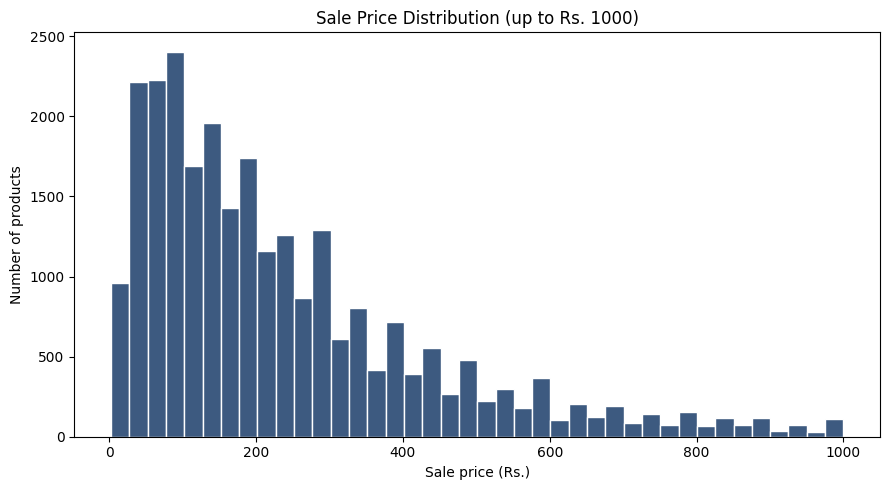

In [85]:
plt.figure(figsize=(9, 5))
plt.hist(sale[sale <= 1000], bins=40, color="#3D5A80", edgecolor="white")
plt.title("Sale Price Distribution (up to Rs. 1000)")
plt.xlabel("Sale price (Rs.)")
plt.ylabel("Number of products")
plt.tight_layout()
plt.show()

# Section 10: Images as Arrays

A grayscale image is just a **2D array of numbers**: `0` is black and `255` is white. This is a nice way to see that a NumPy array can represent real things.

In [86]:
image = np.array([ [0, 50, 100, 150, 200],
                  [200, 150, 100, 50, 0],
                  [0, 100, 200, 100, 0],
                  [50, 150, 200, 150, 50],
                  [255, 200, 150, 100, 50]])

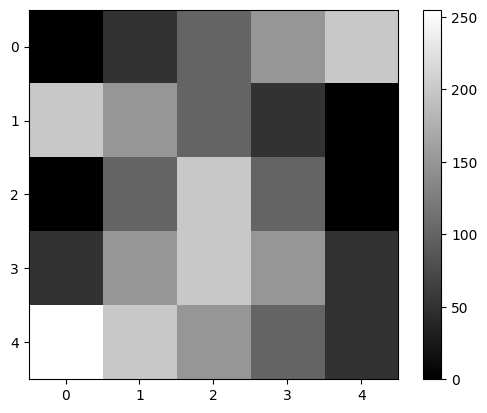

In [87]:
plt.imshow(image, cmap='gray')
plt.colorbar()
plt.show()

Slicing works on images too. This takes the top-left 2x2 block:

In [88]:
image[:2, :2]

array([[  0,  50],
       [200, 150]])

# Section 11: Summary

## Summary

| Topic | Key functions |
|-------|---------------|
| Create arrays | `np.array`, `np.zeros`, `np.ones`, `np.full`, `np.arange`, `np.linspace`, `np.eye`, `rng.integers` |
| Attributes | `.shape`, `.dtype`, `.size`, `.ndim` |
| Convert types | `.astype()` |
| Operations | `+ - * / **`, broadcasting, `np.sqrt`, `np.round`, `np.abs` |
| Statistics | `np.sum`, `np.mean`, `np.median`, `np.std`, `np.min`, `np.max`, `np.percentile`, `axis` |
| Select data | `arr[i]`, `arr[a:b]`, `arr[r, c]`, fancy indexing, `arr[arr > x]` |
| Conditions | `np.where`, `&`, `\|`, `~` |
| Reshape and sort | `.reshape`, `.flatten`, `.T`, `np.sort`, `np.argsort`, `np.unique` |
| Combine | `np.concatenate`, `np.vstack`, `np.hstack` |
| Missing values | `np.nan`, `np.isnan`, `np.nanmean` |

*Next notebook: Pandas Data Analysis.*